In [1]:
from __future__ import division
import numpy as np
from numpy.random import rand
import matplotlib.pyplot as plt
import matplotlib as mpl
from numba import jit
import os
import re
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.model_selection import KFold
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [2]:
plt.rcParams.update({'font.size': 12,
                     'lines.linewidth': 3,
                     'lines.markersize': 10,
                     "font.family": "serif",
                     'font.weight': 'normal',
                     "mathtext.fontset" : "stix",
                     "figure.dpi":200,
                     "legend.title_fontsize":12,
                     "legend.fontsize":9
                     })

In [3]:
device = (
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Using {device} device")

Using mps device


In [4]:
def sort_beta(file):
    #print(file)
    beta = re.search('beta_(.+?)_', file).group(1)
    return float(beta)

In [5]:
N_vals=[0, 10, 20, 30, 40]
type_folder = 'Hex_antiferro_v2'
Network_folder = 'antiferro'

In [6]:

c_norm = mpl.colors.Normalize(vmin=np.min(N_vals), vmax=np.max(N_vals))

# Pick a colormap
c_map1  = mpl.cm.Blues

# Scalar mappable of normalized array to colormap
s_map1  = mpl.cm.ScalarMappable(cmap=c_map1, norm=c_norm)
s_map1.set_array([])

# Pick a colormap
c_map2  = mpl.cm.Reds

# Scalar mappable of normalized array to colormap
s_map2  = mpl.cm.ScalarMappable(cmap=c_map2, norm=c_norm)
s_map2.set_array([])

In [7]:
class Net(nn.Module):
    def __init__(self):
        super().__init__()

        self.layers = nn.Sequential(nn.Linear(N**2,50 ),
                                    nn.ReLU(),
                                    nn.Linear(50,2),
                                    nn.Softmax()
                                    )
    def forward(self, x):
        return self.layers(x)

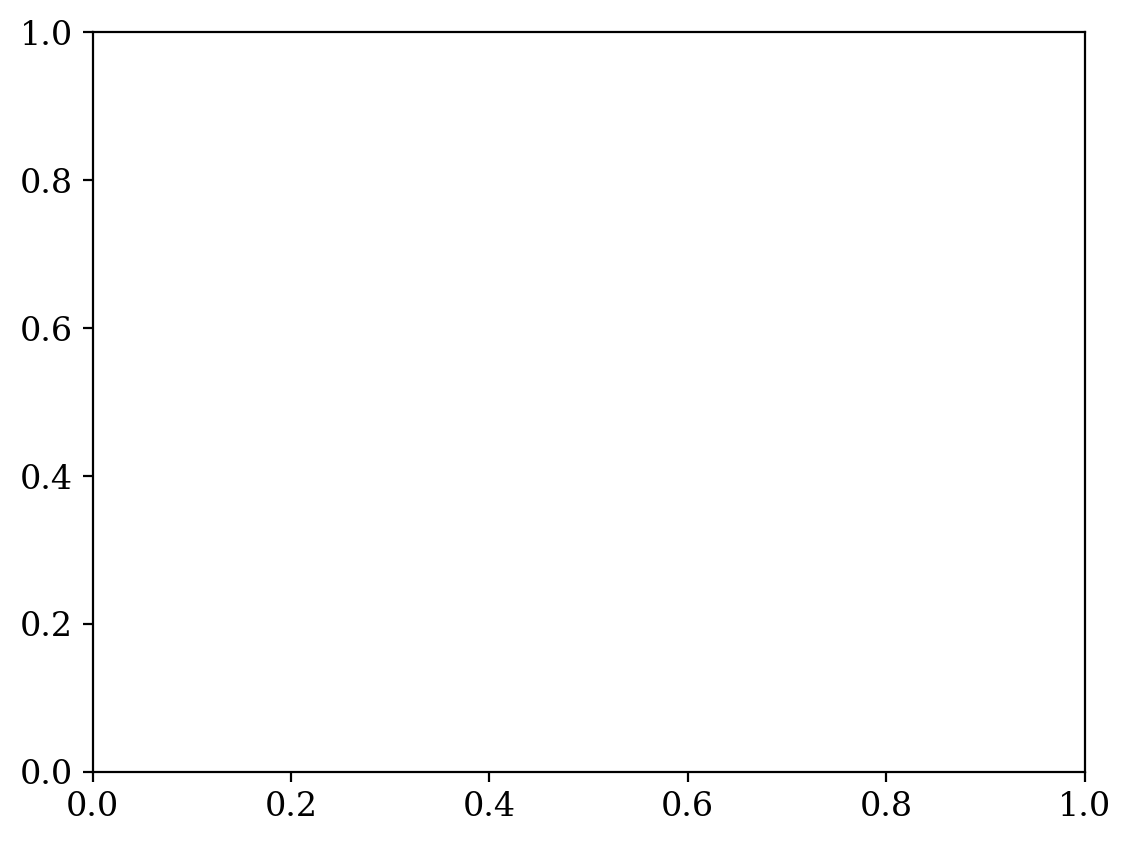

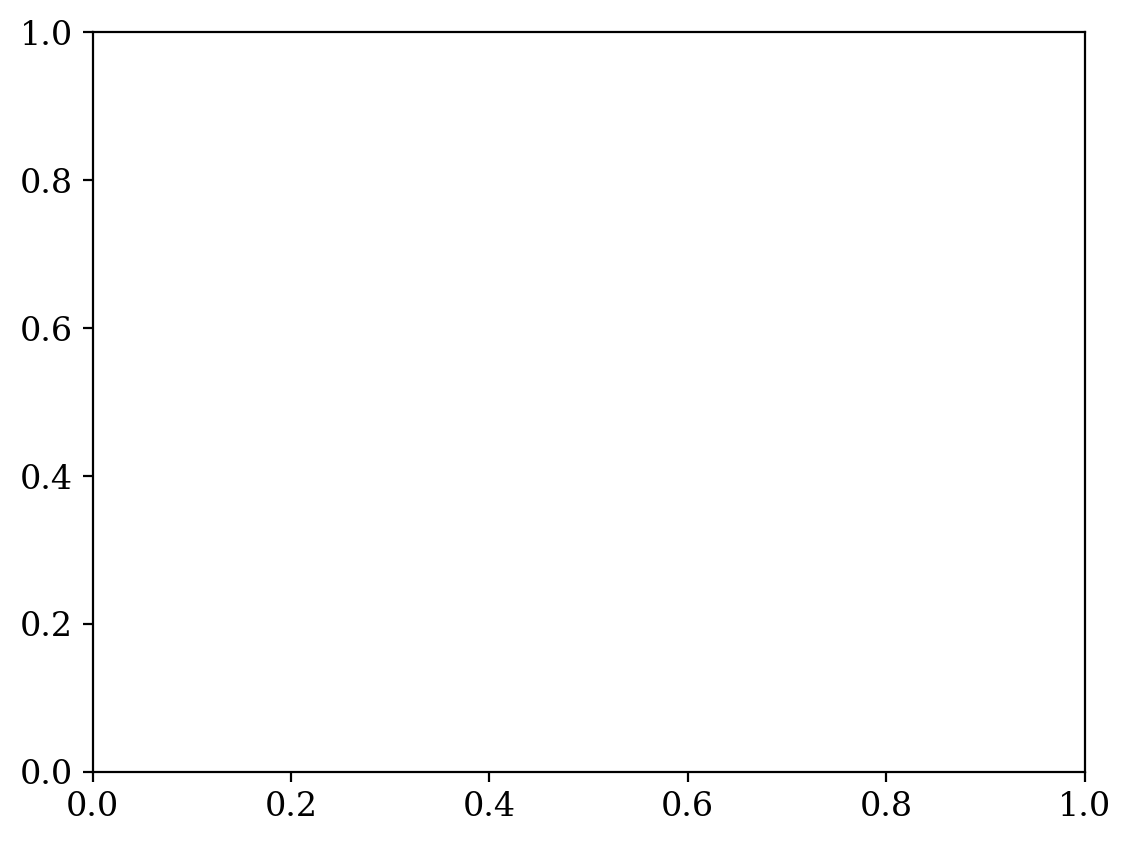

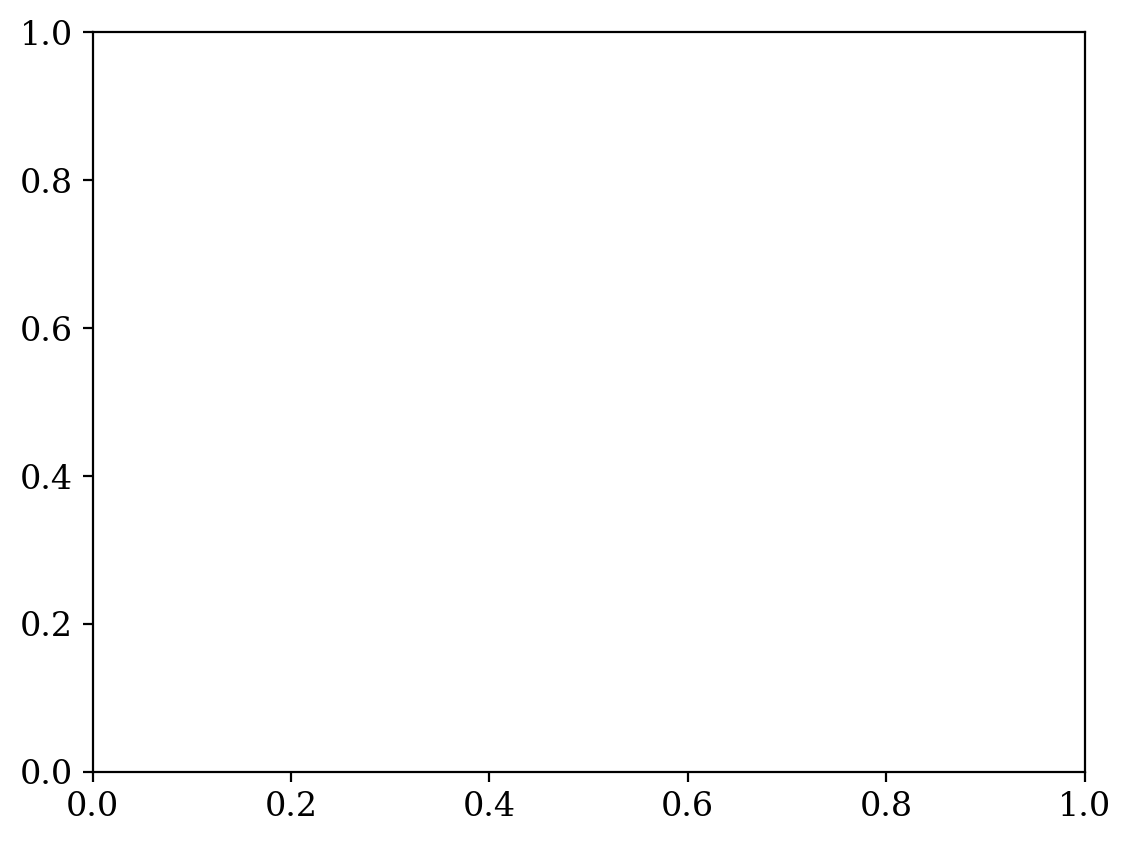

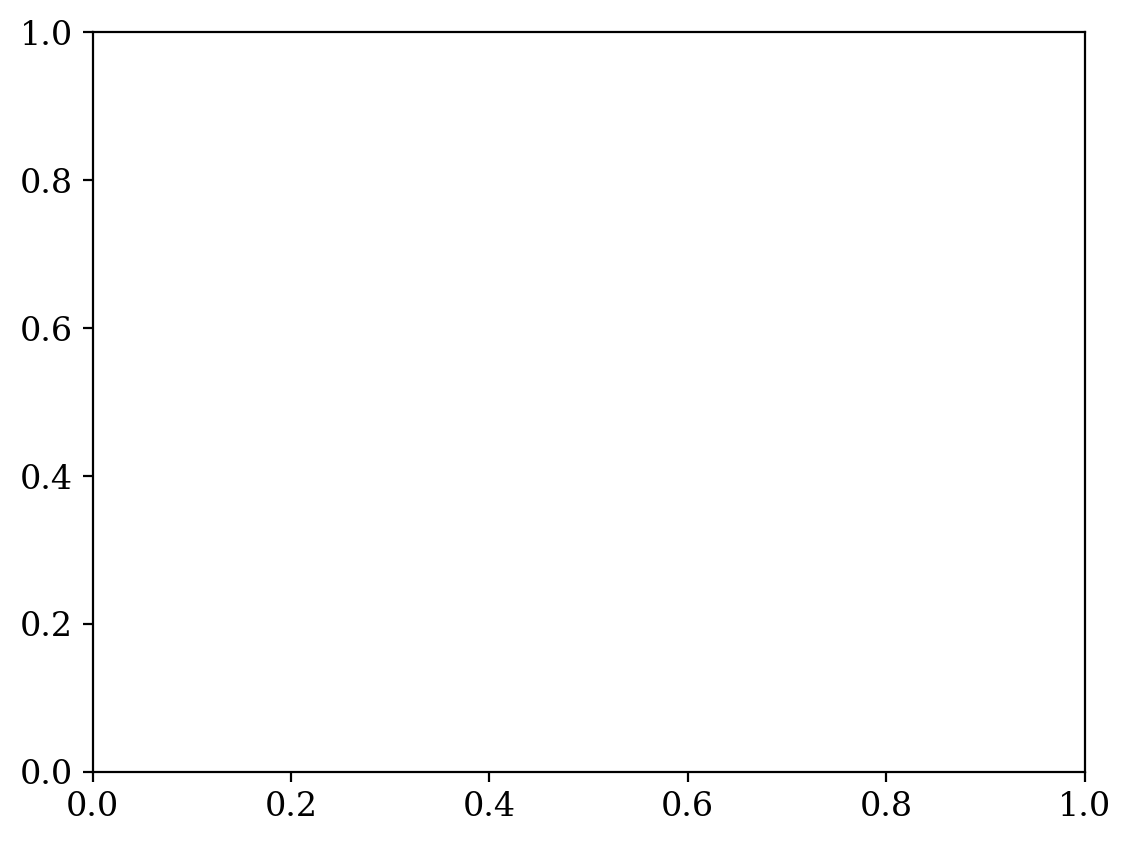

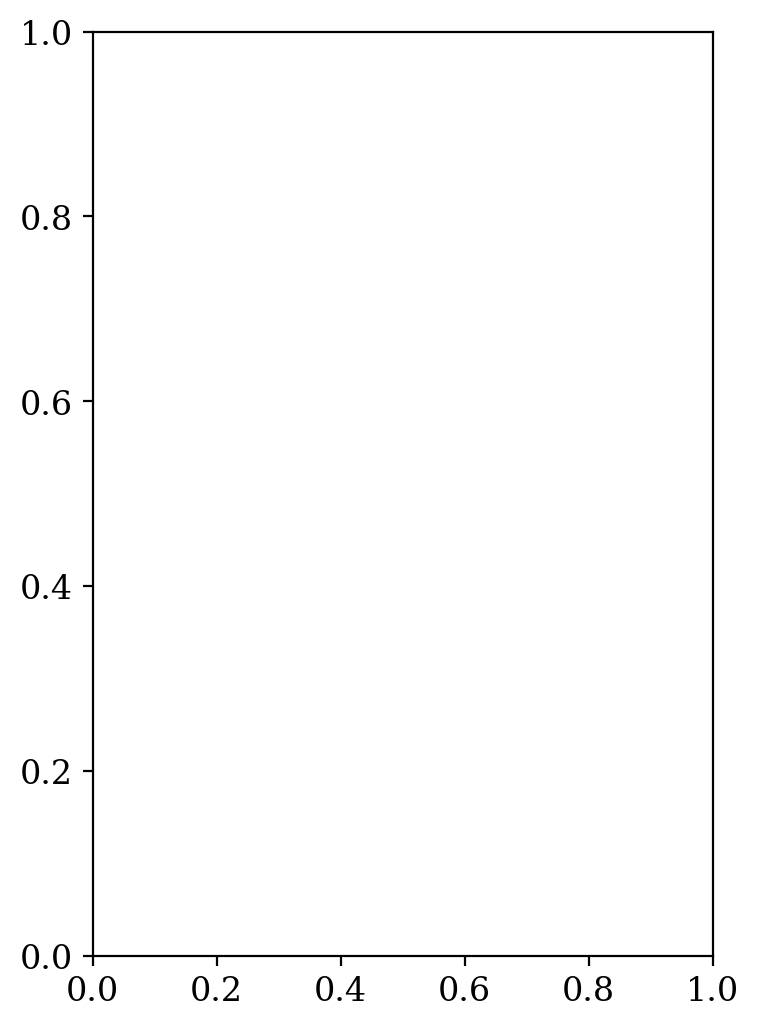

In [8]:
fig_avg, ax_avg = plt.subplots();
fig_blkavg, ax_blkavg = plt.subplots();
fig_blkavg2, ax_blkavg2 = plt.subplots();
fig_all, ax_all =plt.subplots();
fig_4, ax_4 = plt.subplots(figsize=(4, 6));

In [9]:
numCopies =2

for N in N_vals[1:]:

    inputfolder ='./'+type_folder+'/data_N_'+str(N)+'_test'
    myfiles = os.listdir(inputfolder)
    #myfiles.remove('.DS_Store')
    myfiles.sort(key = sort_beta)
    
    PATH = './'+Network_folder+'_FeedForwardNetworks/net_N_'+str(N)+'_.pth'
    net = Net()
    net.load_state_dict(torch.load(PATH))
    
    betas= []
    labels = []
    data = np.zeros((  int(len(myfiles)) ,N,N))
    for i in range(len(myfiles)):
        #print(myfiles[i])

        beta = re.search('beta_(.+?)_', myfiles[i]).group(1)
        betas.append(float(beta))
        data[i,:] = np.loadtxt(inputfolder+'/'+str(myfiles[i]))
        if 1/float(beta) > 2.269:
            labels.append(0) #paramagnet above Tc
        else: labels.append(1) #ferromagnet below Tc
    
    data = np.repeat(data, numCopies, axis=0)
    print(data.shape)

    #flip half of the spins at each temperature to double configurations in data
    for i in range(int(len(data)/int(numCopies/2))):
        if (i % 2) == 0:
            #print(i*int(numCopies/2),(i+1)*int(numCopies/2))
            data[i*int(numCopies/2):(i+1)*int(numCopies/2)]*=-1
    
    X = torch.from_numpy(data)
    X= torch.tensor(X, dtype=torch.float)

    X = X.reshape(X.shape[0], -1)

    y = np.asarray(labels)
    y=np.repeat(y,numCopies)
    print(y.shape)
    y = torch.from_numpy(y)
    y= torch.tensor(y, dtype=torch.long)

    betas=np.asarray(betas)
    betas = np.repeat(betas, numCopies)
    #print(betas.shape)

    outputs = net(X)
    outputs = outputs.detach().numpy()
    #print(outputs)
    #print(X.shape)
    #print(outputs.shape)
    #print(y)
    #print(betas)

    #print(numCopies)


    numT = int(len(betas)/numCopies)

    beta_vals=np.zeros(numT)
    ferro= np.zeros(numT)
    para=np.zeros(numT)

    ferro_std= np.zeros(numT)
    para_std=np.zeros(numT)


    for i in range(numT):
        beta_vals[i] = np.mean(betas[i*numCopies:(i+1)*numCopies])
        #print(np.mean(outputs[i*numCopies:(i+1)*numCopies, 0]))
        #print(np.std(outputs[i*numCopies:(i+1)*numCopies, 0]))

        ferro[i] = np.mean(outputs[i*numCopies:(i+1)*numCopies, 1])
        ferro_std[i] = np.std(outputs[i*numCopies:(i+1)*numCopies, 1])

        #print(ferro[i])
        #print(outputs[i*numCopies:(i+1)*numCopies, 0])
        #print(ferro[i])
        para[i]  = np.mean(outputs[i*numCopies:(i+1)*numCopies, 0])
        para_std[i] = np.std(outputs[i*numCopies:(i+1)*numCopies, 0])

        #print(outputs[i*numCopies:(i+1)*numCopies, 1])
        #print(para[i])

    # print(para_std)
    # print(ferro_std)
    # print(np.where(para_std >10**-7))
    # print(np.where(ferro_std >10**-7))


    ##### Block averaging the data

    bsize= 100
    bAvgFerro = np.zeros(int(len(ferro)/bsize))
    bAvgPara = np.zeros(int(len(para)/bsize))
    bAvgBeta = np.zeros(int(len(beta_vals)/bsize))
    bStdFerro = np.zeros(int(len(ferro)/bsize))
    bStdPara = np.zeros(int(len(para)/bsize))
    bStdBeta = np.zeros(int(len(beta_vals)/bsize))

    for i in range(int(len(ferro)/bsize)):
        #bAvgFerro[i] = np.sum( ferro[i*bsize:(i+1)*bsize])/bsize
        bAvgFerro[i] = np.mean( ferro[i*bsize:(i+1)*bsize])
        bStdFerro[i] = np.std( ferro[i*bsize:(i+1)*bsize])
        #bAvgPara[i]  = np.sum( para[i*bsize:(i+1)*bsize])/bsize
        bAvgPara[i]  = np.mean( para[i*bsize:(i+1)*bsize])
        bStdPara[i]  = np.std( para[i*bsize:(i+1)*bsize])
        #bAvgBeta[i]  = np.sum( beta_vals[i*bsize:(i+1)*bsize])/bsize
        bAvgBeta[i]  = np.mean( beta_vals[i*bsize:(i+1)*bsize])
        bStdBeta[i]  = np.std( beta_vals[i*bsize:(i+1)*bsize])

    #####


    #plt.figure()
    ax_avg.scatter(1/beta_vals, ferro, s=1, label='ferromagnetic')
    ax_avg.scatter(1/beta_vals, para, s=1, label='paramagnetic')
    #ax_avg.plot(np.ones(len(beta_vals))*2.266, np.linspace(0,1, len(beta_vals)), color='black' )
    ax_avg.set_xlabel(r'$k_{B}T/J$')
    ax_avg.set_ylabel('output layer')
    ax_avg.set_title('Average')
    fig_avg.legend()

    #plt.figure()

    ax_blkavg.plot(1/bAvgBeta, bAvgFerro, color = s_map1.to_rgba(float(N)), label= 'L = '+str(N), marker = '.')
    ax_blkavg.plot(1/bAvgBeta, bAvgPara, color = s_map2.to_rgba(float(N)), marker='.')
    
    ax_blkavg.plot(np.ones(len(bAvgBeta))*3.67, np.linspace(0,1, len(bAvgBeta)),
                   linewidth =3, color='black',linestyle='dashed')
    
    ax_blkavg2.errorbar(1/bAvgBeta, bAvgFerro, yerr=bStdFerro, 
                 color = s_map1.to_rgba(float(N)), ecolor=s_map1.to_rgba(float(N)), elinewidth=None, 
                 capsize=0, label= 'L = '+str(N), marker = '.')

    ax_blkavg2.errorbar(1/bAvgBeta, bAvgPara, yerr=bStdPara, 
                 color = s_map2.to_rgba(float(N)), ecolor=s_map2.to_rgba(float(N)), elinewidth=None, 
                 capsize=0, marker = '.')


    ax_blkavg.set_xlabel(r'$\mathrm{k_{B}T/J}$', fontsize=18)
    ax_blkavg.set_ylabel('output layer', fontsize=18)
    ax_blkavg.set_title('Block Average')
    ax_blkavg.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left',  frameon=False)
    #fig_blkavg.legend()
    #ax_blkavg.set_xlim(2,5.5)

    ax_blkavg2.set_xlabel(r'$\mathrm{k_{B}T/J}$')
    ax_blkavg2.set_ylabel('output layer')
    ax_blkavg2.set_title('Block Average')
    #fig_blkavg2.legend()
    
    nu=1.0 #finite size scaling critical exponent
    t= (1/bAvgBeta- 3.67)
    ax_4.plot(t*N**(1/nu), bAvgFerro, color = s_map1.to_rgba(float(N)), label= 'L = '+str(N), marker = '.')
    ax_4.plot(t*N**(1/nu), bAvgPara, color = s_map2.to_rgba(float(N)), marker='.')
    ax_4.plot(np.ones(len(bAvgBeta))*0, np.linspace(0,1, len(bAvgBeta)),
                   linewidth =3, color='black',linestyle='dashed')
    ax_4.set_xlim(-15,15)
    ax_4.set_xlabel(r'$\mathrm{N^{1/\nu}k_{B}\left(T-T_{c}\right)/J}$', fontsize=18)
    ax_4.set_ylabel('output layer', fontsize=18)
    ax_4.set_title('Data Collapse')
    #fig_4.legend()
    
    #plt.figure()
    ax_all.scatter(1/betas, outputs[:,1], s=1, label='ferromagnetic')
    ax_all.scatter(1/betas, outputs[:,0], s=1, label='paramagnetic')
    ax_all.set_xlabel(r'$k_{B}T/J$')
    ax_all.set_ylabel('Output layer')
    ax_all.set_title('All data')
    fig_all.legend()
    


    

(4000, 10, 10)
(4000,)


/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_23722/3959154623.py:37: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X= torch.tensor(X, dtype=torch.float)
/var/folders/c3/v12nq2x14cq73wqt20_541t80000gp/T/ipykernel_23722/3959154623.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  y= torch.tensor(y, dtype=torch.long)
/Users/GBordia/anaconda3/envs/c142/lib/python3.8/site-packages/torch/nn/modules/module.py:1511: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


(4000, 20, 20)
(4000,)
(4000, 30, 30)
(4000,)
(4000, 40, 40)
(4000,)


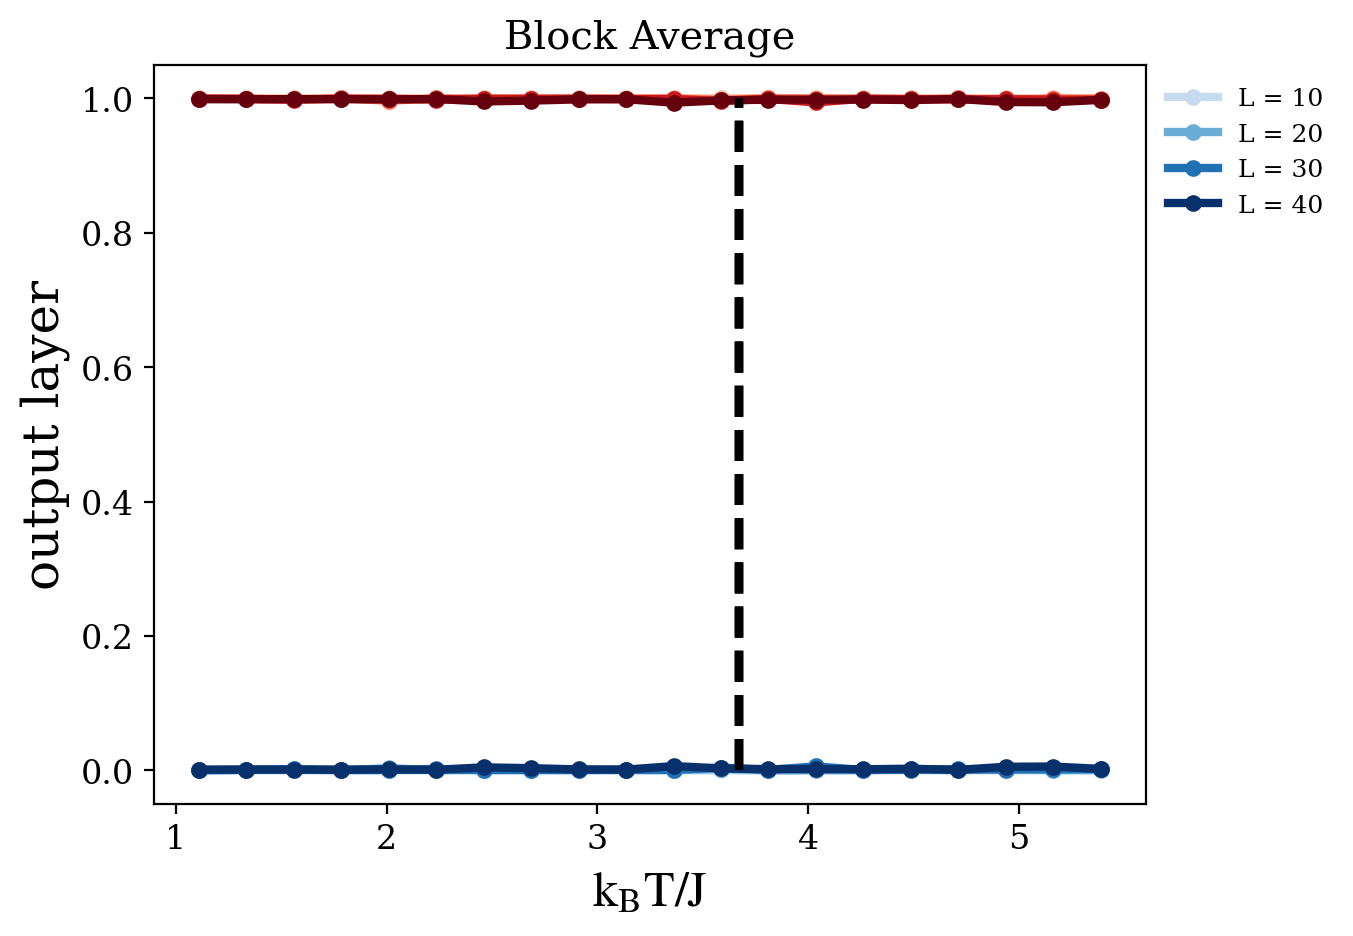

In [10]:
fig_blkavg

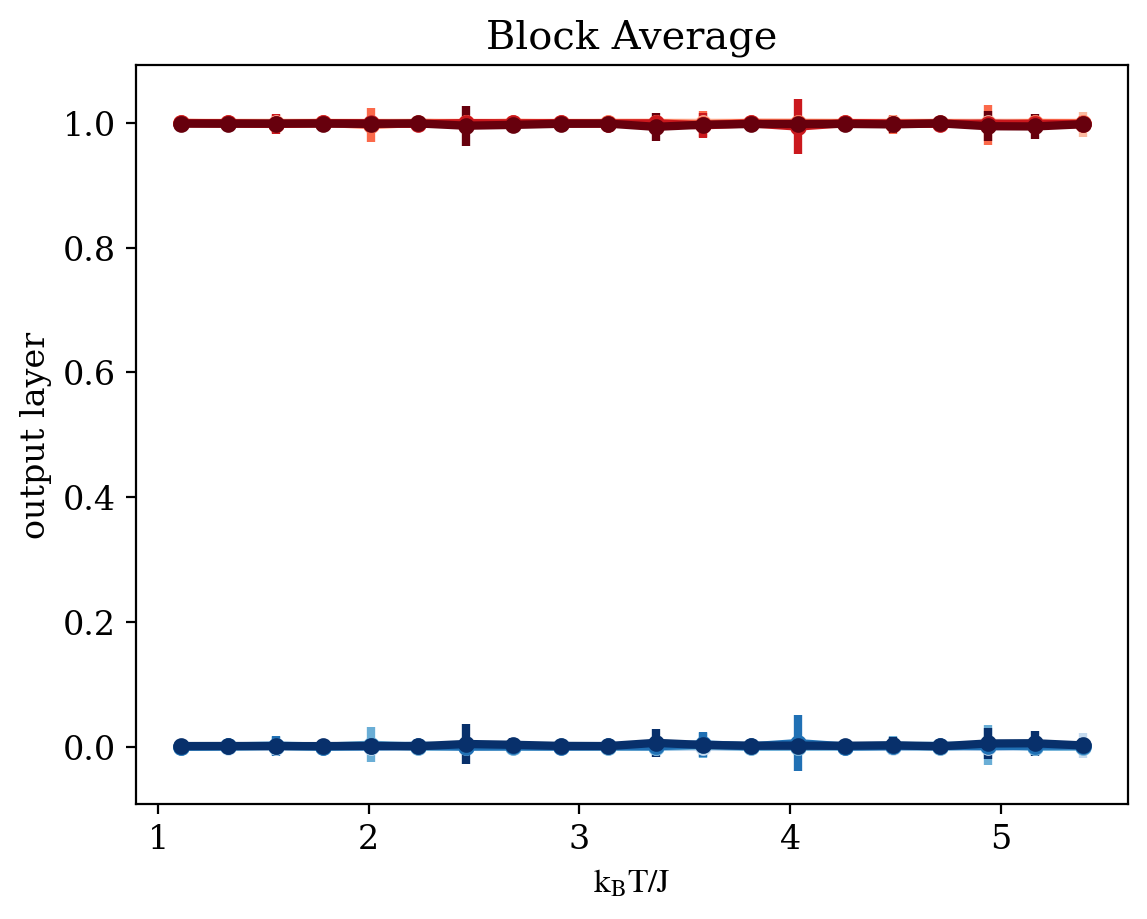

In [11]:
fig_blkavg2

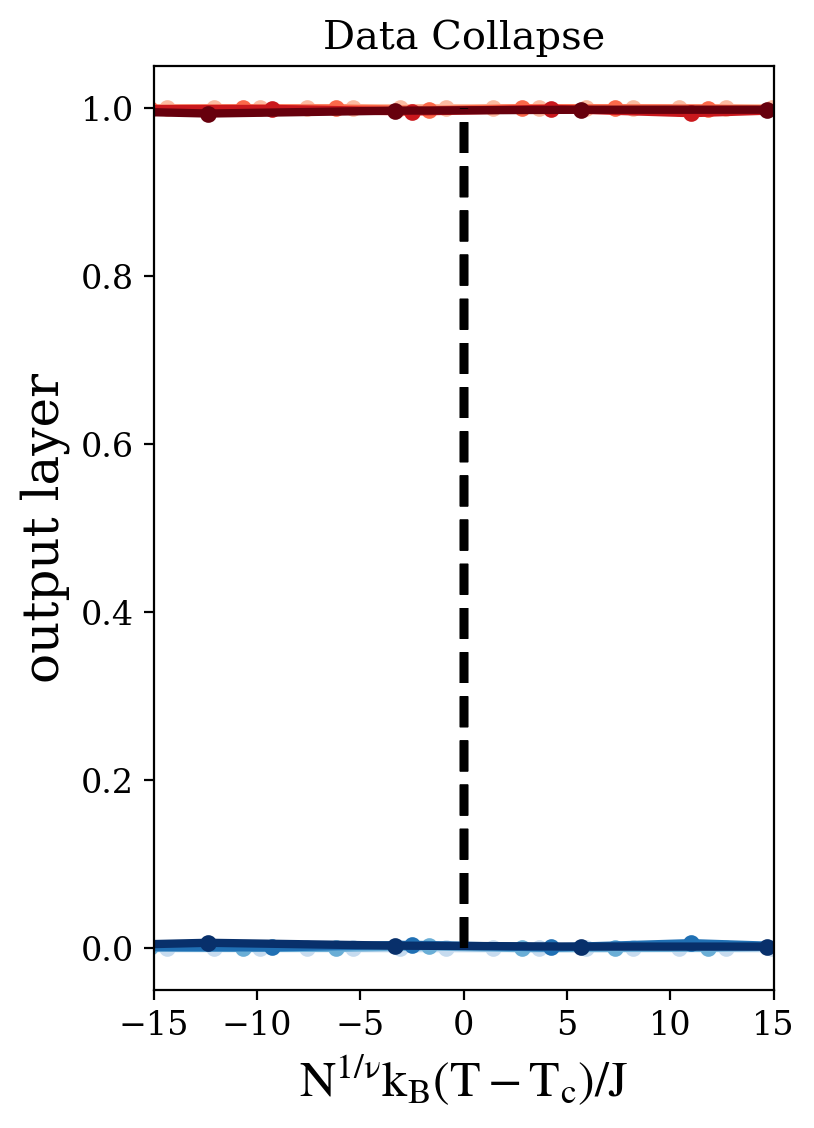

In [12]:
fig_4